<a href="https://colab.research.google.com/github/Moriarty7819/Credit-Scoring/blob/main/Credit_Scoring.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [3]:
df=pd.read_csv("/content/cs-training.csv")

In [4]:
df.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [5]:
df.isnull().sum()

,0
Unnamed: 0,0
SeriousDlqin2yrs,0
RevolvingUtilizationOfUnsecuredLines,0
age,0
NumberOfTime30-59DaysPastDueNotWorse,0
DebtRatio,0
MonthlyIncome,29731
NumberOfOpenCreditLinesAndLoans,0
NumberOfTimes90DaysLate,0
NumberRealEstateLoansOrLines,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  

In [7]:
df = df.dropna()

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 120269 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            120269 non-null  int64  
 1   SeriousDlqin2yrs                      120269 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  120269 non-null  float64
 3   age                                   120269 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  120269 non-null  int64  
 5   DebtRatio                             120269 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       120269 non-null  int64  
 8   NumberOfTimes90DaysLate               120269 non-null  int64  
 9   NumberRealEstateLoansOrLines          120269 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  120269 non-null  int64  
 11  Numbe

In [9]:
df['SeriousDlqin2yrs'].value_counts()


,count
SeriousDlqin2yrs,
0,111912
1,8357


In [10]:
df = df.drop(columns=['Unnamed: 0'])


In [11]:
df.isnull().sum()


,0
SeriousDlqin2yrs,0
RevolvingUtilizationOfUnsecuredLines,0
age,0
NumberOfTime30-59DaysPastDueNotWorse,0
DebtRatio,0
MonthlyIncome,0
NumberOfOpenCreditLinesAndLoans,0
NumberOfTimes90DaysLate,0
NumberRealEstateLoansOrLines,0
NumberOfTime60-89DaysPastDueNotWorse,0


In [12]:
X = df.drop('SeriousDlqin2yrs', axis=1)
y = df['SeriousDlqin2yrs']

#train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
     stratify=y
)

In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
model = LogisticRegression(max_iter=1000)


In [15]:
model.fit(X_train_scaled, y_train)


LogisticRegression(max_iter=1000)

In [16]:
y_pred = model.predict(X_test_scaled)


In [17]:
y_proba = model.predict_proba(X_test_scaled)[:, 1]


ROC-AUC: 0.6865969147686862


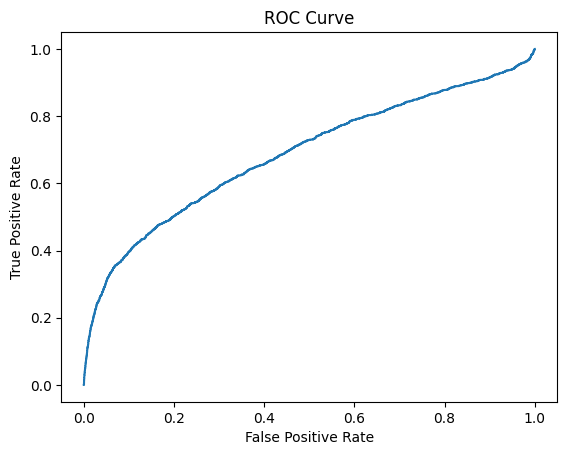

In [18]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

auc = roc_auc_score(y_test, y_proba)
print("ROC-AUC:", auc)

fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

# test different probability thresholds
thresholds = [0.2, 0.3, 0.5, 0.7, 0.8]

for t in thresholds:
    print(f"\n===== Threshold = {t} =====")

    # convert probabilities into class predictions
    y_pred_t = (y_proba > t).astype(int)

    # calculate metrics
    acc = accuracy_score(y_test, y_pred_t)
    prec = precision_score(y_test, y_pred_t, zero_division=0)
    rec = recall_score(y_test, y_pred_t, zero_division=0)
    cm = confusion_matrix(y_test, y_pred_t)

    # print results
    print("Accuracy :", round(acc, 4))
    print("Precision:", round(prec, 4))
    print("Recall   :", round(rec, 4))
    print("Confusion matrix:")
    print(cm)


===== Threshold = 0.2 =====
Accuracy : 0.9276
Precision: 0.4455
Recall   : 0.1735
Confusion matrix:
[[22022   361]
 [ 1381   290]]

===== Threshold = 0.3 =====
Accuracy : 0.9306
Precision: 0.5034
Recall   : 0.0892
Confusion matrix:
[[22236   147]
 [ 1522   149]]

===== Threshold = 0.5 =====
Accuracy : 0.9313
Precision: 0.5789
Recall   : 0.0395
Confusion matrix:
[[22335    48]
 [ 1605    66]]

===== Threshold = 0.7 =====
Accuracy : 0.9311
Precision: 0.625
Recall   : 0.0209
Confusion matrix:
[[22362    21]
 [ 1636    35]]

===== Threshold = 0.8 =====
Accuracy : 0.9307
Precision: 0.619
Recall   : 0.0078
Confusion matrix:
[[22375     8]
 [ 1658    13]]


In [20]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

coefficients = coefficients.sort_values(by='Coefficient', ascending=False)
print(coefficients)

                                Feature  Coefficient
2  NumberOfTime30-59DaysPastDueNotWorse     1.728315
6               NumberOfTimes90DaysLate     1.543443
9                    NumberOfDependents     0.112732
7          NumberRealEstateLoansOrLines     0.105972
0  RevolvingUtilizationOfUnsecuredLines    -0.008724
5       NumberOfOpenCreditLinesAndLoans    -0.023832
3                             DebtRatio    -0.107979
1                                   age    -0.368627
4                         MonthlyIncome    -0.679831
8  NumberOfTime60-89DaysPastDueNotWorse    -3.118345
